# Série de Renda Fixa (*risk-free*) Diária — 1990–2025

Constrói a série diária de taxa livre de risco usada para calcular **retornos excedentes** e o **fator de mercado** ($R_m - R_f$) das regressões de fatores.

A base do professor traz `Rf.csv` cobrindo **1990-07-03 a 2015-12-30** (6.425 dias). A `base_unificada` vai até **2025-12-31** (8.939 dias), então faltam **2.514 dias** (2016–2025). Este notebook:

1. Carrega a série do professor e recupera suas datas (o arquivo não tem cabeçalho nem coluna de data — o alinhamento é posicional com `professor_consolidado.csv`)
2. Baixa candidatos de T-bill do **FRED**
3. **Valida na sobreposição de 25 anos** qual série e qual conversão anual→diária reproduzem a série do professor
4. Confere a **costura** na virada 2015/2016
5. Emenda as duas e salva `rf_diario.csv` alinhado aos 8.939 dias da base

---

> ⚠️ **Atenção — armadilha de nome.** Os arquivos `data_bases/prices/RF.csv` e `data_bases/prices_sobreposição/RF.csv` **não são renda fixa**: são preços da ação *Regions Financial* (ticker `RF`), constituinte do S&P 500 e coletada junto com as demais. `RF` também é uma coluna de ticker em `base_unificada.csv`. A única fonte de taxa livre de risco é `data_bases/professor/Rf.csv`.

**Convenção dos artigos.** Gatev et al. (2006) usam a T-bill de 30 dias; Sabino da Silva, Ziegelmann & Caldeira (2023) puxam os fatores da biblioteca do Ken French. A validação abaixo mostra que a série do professor é compatível com a **T-bill de 3 meses** convertida geometricamente para base diária de 252 dias.

In [1]:
import io

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Fonte da extensão (2016–2025) ─────────────────────────────────────────────
FRED_SERIE = 'DTB3'   # 3-Month Treasury Bill, Secondary Market Rate (Discount Basis)
                      # escolhida pela validação da seção 3 — não altere sem re-rodar
FRED_URL   = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id={}'

# Candidatos comparados na validação (todos cobrem 1990–2015 inteiro)
CANDIDATOS = ['DTB3', 'DGS3MO', 'DTB6', 'DGS6MO']

# ── Conversão taxa anual → taxa diária ────────────────────────────────────────
DIAS_ANO  = 252
CONVERSAO = 'geometrica'  # 'geometrica' → (1 + i_a)^(1/252) − 1
                          # 'linear'     → i_a / 252
CASAS     = 6             # o arquivo do professor está arredondado a 6 casas decimais

# ── Taxa negativa ─────────────────────────────────────────────────────────────
# A T-bill de 3 meses negociou com taxa negativa em 25 e 26/mar/2020, no auge da
# fuga para qualidade da COVID. Não é erro de dado.
#   False → mantém o valor negativo (dado de mercado real)
#   True  → trunca em zero
PISO_ZERO = False

# ── Arquivos ──────────────────────────────────────────────────────────────────
PATH_RF_PROF = '../../data_bases/professor/Rf.csv'
PATH_DATAS   = '../../data_bases/professor_consolidado.csv'
PATH_BASE    = '../../data_bases/base_unificada.csv'
PATH_SAIDA   = '../../data_bases/rf_diario.csv'


def converter(anual_pct, modo=CONVERSAO, dias=DIAS_ANO):
    """Taxa anual em % (ex.: 5.25) → taxa diária em decimal (ex.: 0.000203)."""
    i = anual_pct / 100.0
    if modo == 'geometrica':
        return (1 + i) ** (1 / dias) - 1
    if modo == 'linear':
        return i / dias
    raise ValueError(f"conversão desconhecida: {modo!r}")


def anualizar(diaria, modo=CONVERSAO, dias=DIAS_ANO):
    """Inverso de converter(): taxa diária decimal → taxa anual em %."""
    if modo == 'geometrica':
        return ((1 + diaria) ** dias - 1) * 100
    return diaria * dias * 100

## 1. Série do professor (1990–2015)

`Rf.csv` não tem cabeçalho nem coluna de data: é uma coluna solta de 6.425 taxas **diárias**, na mesma ordem das linhas de `professor_consolidado.csv`. O `assert` abaixo é o que garante que o alinhamento posicional é válido.

In [2]:
datas_prof = pd.read_csv(PATH_DATAS, parse_dates=['date'], usecols=['date'])['date']
rf_prof    = pd.read_csv(PATH_RF_PROF, header=None, names=['rf'])['rf']

assert len(rf_prof) == len(datas_prof), (
    f"Rf.csv tem {len(rf_prof)} linhas mas professor_consolidado.csv tem {len(datas_prof)} — "
    "o alinhamento posicional não é válido."
)

rf_prof.index      = pd.DatetimeIndex(datas_prof)
rf_prof.index.name = 'date'

print(f"Dias                : {len(rf_prof):,}")
print(f"Período             : {rf_prof.index[0].date()} → {rf_prof.index[-1].date()}")
print(f"Taxa diária (min–máx): {rf_prof.min():.6f} – {rf_prof.max():.6f}")
print(f"Média anualizada    : {anualizar(rf_prof.mean()):.2f}% a.a.")
print(f"Dias com taxa zero  : {(rf_prof == 0).sum()} "
      f"(anos: {sorted(rf_prof[rf_prof == 0].index.year.unique().tolist())})")
print(f"Valores ausentes    : {rf_prof.isna().sum()}")

Dias                : 6,425
Período             : 1990-07-03 → 2015-12-30
Taxa diária (min–máx): 0.000000 – 0.000291
Média anualizada    : 2.80% a.a.
Dias com taxa zero  : 21 (anos: [2011])
Valores ausentes    : 0


In [3]:
# Média anualizada por ano — deve seguir a história da T-bill americana
por_ano = anualizar(rf_prof.groupby(rf_prof.index.year).mean()).round(2)
print("Taxa média anualizada por ano (%):\n")
print(por_ano.to_string())

Taxa média anualizada por ano (%):

date
1990    7.24
1991    5.38
1992    3.43
1993    3.00
1994    4.26
1995    5.48
1996    5.01
1997    5.06
1998    4.77
1999    4.65
2000    5.82
2001    3.38
2002    1.60
2003    1.01
2004    1.38
2005    3.16
2006    4.73
2007    4.34
2008    1.35
2009    0.16
2010    0.14
2011    0.05
2012    0.09
2013    0.06
2014    0.03
2015    0.06


## 2. Baixando os candidatos do FRED

O FRED publica em **dias corridos úteis**, com valor vazio em feriados americanos. Fazemos `ffill` na grade do próprio FRED (propaga o último pregão) *antes* de reindexar para os dias da nossa base.

In [4]:
def baixar_fred(serie_id, url=FRED_URL, timeout=60):
    """Baixa uma série diária do FRED e devolve pd.Series (taxa anual em %) indexada por data."""
    resp = requests.get(url.format(serie_id), timeout=timeout)
    resp.raise_for_status()
    df = pd.read_csv(io.StringIO(resp.text), parse_dates=['observation_date'])
    s  = df.set_index('observation_date')[serie_id]
    s  = pd.to_numeric(s, errors='coerce')   # feriados vêm como '.' → NaN
    s.index.name = 'date'
    return s.sort_index()


series_fred = {}
for sid in CANDIDATOS:
    try:
        s = baixar_fred(sid)
        series_fred[sid] = s
        print(f"{sid:8s} {s.index.min().date()} → {s.index.max().date()} | "
              f"{len(s):,} obs | {s.isna().sum():,} vazios (feriados)")
    except Exception as e:
        print(f"{sid:8s} FALHOU: {type(e).__name__}: {e}")

assert FRED_SERIE in series_fred, f"A série escolhida ({FRED_SERIE}) não foi baixada — sem ela não dá para seguir."

DTB3     1954-01-04 → 2026-08-13 | 18,944 obs | 799 vazios (feriados)
DGS3MO   1981-09-01 → 2026-08-13 | 11,728 obs | 491 vazios (feriados)
DTB6     1958-12-09 → 2026-08-13 | 17,658 obs | 753 vazios (feriados)
DGS6MO   1981-09-01 → 2026-08-13 | 11,728 obs | 491 vazios (feriados)


## 3. Validação na sobreposição (1990–2015)

Temos **25 anos de sobreposição** entre a série do professor e o FRED — é aqui que se descobre qual série e qual conversão ele usou, em vez de adivinhar.

Duas métricas, ambas em **pontos-base anualizados** (1 bp = 0,01% a.a.):

- **viés**: erro médio com sinal. Perto de zero = mesma série, sem deslocamento sistemático de nível.
- **desvio absoluto médio**: magnitude típica da diferença dia a dia.

O arredondamento a 6 casas do arquivo do professor sozinho já introduz até ~1,3 bp, então um desvio dessa ordem é o piso do que dá para atingir.

In [5]:
linhas = []
for sid, serie in series_fred.items():
    alinhada = serie.ffill().reindex(rf_prof.index)
    for modo in ['geometrica', 'linear']:
        cand = converter(alinhada, modo).round(CASAS)
        dif  = (cand - rf_prof).dropna()
        bp   = dif * DIAS_ANO * 10_000            # pontos-base anualizados
        linhas.append({
            'serie'           : sid,
            'conversao'       : modo,
            'dias'            : len(dif),
            'correlacao'      : cand.corr(rf_prof),
            'vies_bp'         : bp.mean(),
            'desvio_medio_bp' : bp.abs().mean(),
            'desvio_max_bp'   : bp.abs().max(),
            'iguais_6casas_%' : 100 * (dif.abs() < 1e-9).mean(),
        })

validacao = (
    pd.DataFrame(linhas)
    .sort_values('desvio_medio_bp')
    .reset_index(drop=True)
)
display(validacao.round({'correlacao': 6, 'vies_bp': 2, 'desvio_medio_bp': 2,
                          'desvio_max_bp': 2, 'iguais_6casas_%': 1}))

,serie,conversao,dias,correlacao,vies_bp,desvio_medio_bp,desvio_max_bp,iguais_6casas_%
0,DTB3,geometrica,6425,0.999187,-0.09,4.56,110.88,30.9
1,DTB3,linear,6425,0.999153,6.08,8.16,110.88,22.9
2,DGS3MO,geometrica,6425,0.999177,7.17,8.90,110.88,20.3
3,DTB6,geometrica,6425,0.998011,9.65,11.84,103.32,5.6
4,DGS3MO,linear,6425,0.999108,13.71,15.02,110.88,18.9
5,DTB6,linear,6425,0.998072,16.11,16.84,103.32,2.9
6,DGS6MO,geometrica,6425,0.998066,20.45,20.88,105.84,2.2
7,DGS6MO,linear,6425,0.998068,27.47,27.74,123.48,1.8


In [6]:
melhor = validacao.iloc[0]
print(f"Melhor ajuste : {melhor['serie']} / {melhor['conversao']}")
print(f"  viés          : {melhor['vies_bp']:+.2f} bp a.a.")
print(f"  desvio médio  : {melhor['desvio_medio_bp']:.2f} bp a.a.")
print(f"  correlação    : {melhor['correlacao']:.6f}")
print()

if (melhor['serie'], melhor['conversao']) == (FRED_SERIE, CONVERSAO):
    print(f"✓ Confere com a configuração do topo do notebook ({FRED_SERIE} / {CONVERSAO}).")
else:
    print(f"⚠ A configuração do topo é {FRED_SERIE} / {CONVERSAO}, que NÃO é a de melhor ajuste.")
    print("  Revise FRED_SERIE / CONVERSAO antes de gerar o arquivo final.")

Melhor ajuste : DTB3 / geometrica
  viés          : -0.09 bp a.a.
  desvio médio  : 4.56 bp a.a.
  correlação    : 0.999187

✓ Confere com a configuração do topo do notebook (DTB3 / geometrica).


### Comparação visual na sobreposição

O painel de cima sobrepõe as duas séries anualizadas; o de baixo mostra a diferença em pontos-base. O resíduo não some porque o professor coletou de outra fonte (Bloomberg, segundo o artigo) — cotações diárias de T-bill variam ligeiramente entre provedores — e porque o arquivo está arredondado a 6 casas. O que importa é o viés ser ~0: as duas séries medem a mesma coisa, no mesmo nível.

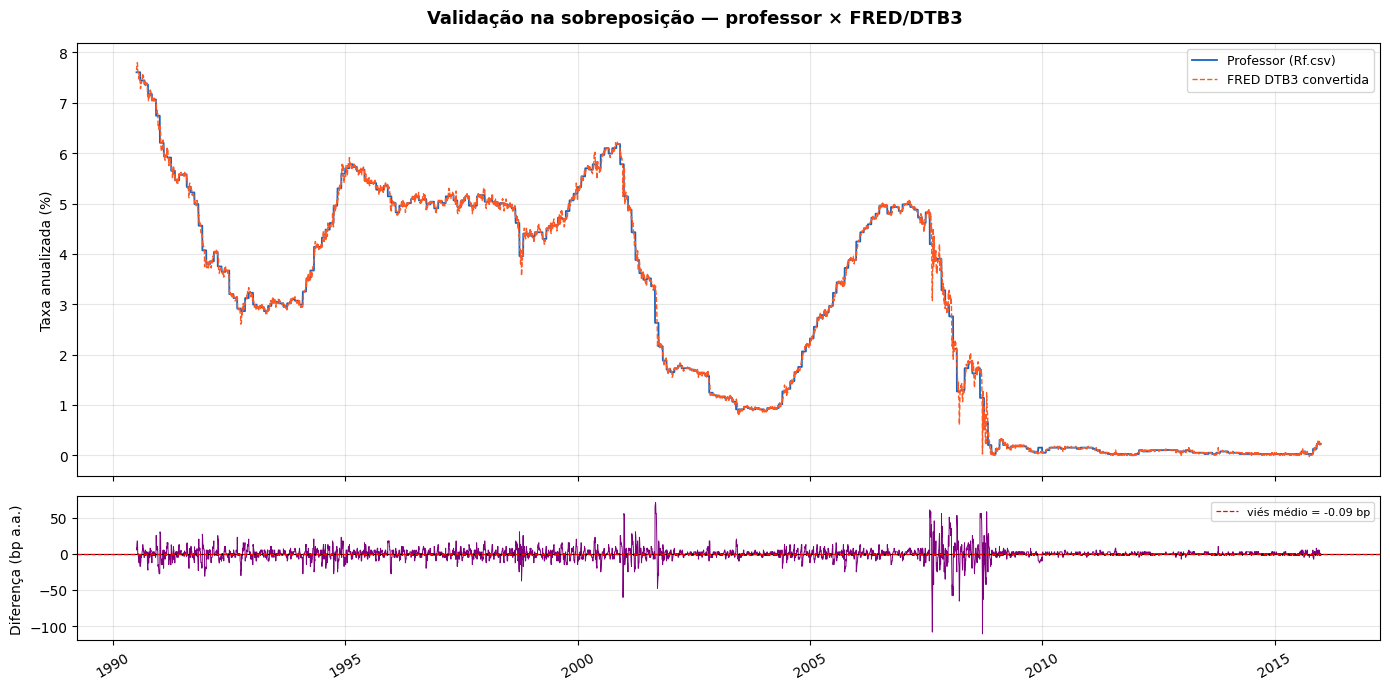

In [7]:
fred_sobrep = converter(series_fred[FRED_SERIE].ffill().reindex(rf_prof.index)).round(CASAS)
dif_bp      = (fred_sobrep - rf_prof) * DIAS_ANO * 10_000

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle(f"Validação na sobreposição — professor × FRED/{FRED_SERIE}",
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(rf_prof.index, anualizar(rf_prof), color='#1565C0', lw=1.3, label='Professor (Rf.csv)')
ax.plot(fred_sobrep.index, anualizar(fred_sobrep), color='#FF5722', lw=1.0, ls='--',
        label=f'FRED {FRED_SERIE} convertida')
ax.set_ylabel('Taxa anualizada (%)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(dif_bp.index, dif_bp.values, color='purple', lw=0.7)
ax.axhline(0, color='black', lw=0.8)
ax.axhline(dif_bp.mean(), color='red', lw=0.9, ls='--',
           label=f'viés médio = {dif_bp.mean():+.2f} bp')
ax.set_ylabel('Diferença (bp a.a.)', fontsize=10)
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.tick_params(axis='x', rotation=30)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. A costura (virada 2015 → 2016)

Emendar duas fontes só é seguro se elas concordarem **exatamente no ponto de junção**. Aqui checamos três coisas:

1. o desvio entre as fontes restrito ao **último ano da sobreposição** (2015) — é o trecho que encosta na emenda, e o que importa é ele, não a média de 25 anos;
2. o **degrau** entre o último valor do professor (2015-12-30) e o primeiro valor da extensão (2016-01-04);
3. o gráfico ampliado da virada, com a série do FRED desenhada também *dentro* de 2015 para ver se ela passa por cima da do professor.

In [8]:
# 1) desvio restrito ao último ano da sobreposição
ult_ano = dif_bp.loc['2015']
print("Último ano da sobreposição (2015):")
print(f"  dias comparados : {len(ult_ano)}")
print(f"  viés            : {ult_ano.mean():+.2f} bp a.a.")
print(f"  desvio médio    : {ult_ano.abs().mean():.2f} bp a.a.")
print(f"  desvio máximo   : {ult_ano.abs().max():.2f} bp a.a.")

# 2) degrau na junção
datas_base = pd.DatetimeIndex(pd.read_csv(PATH_BASE, parse_dates=['date'], usecols=['date'])['date'])
primeira_ext = datas_base[datas_base > rf_prof.index[-1]][0]

rf_fred_full = converter(series_fred[FRED_SERIE].ffill().reindex(datas_base)).round(CASAS)

ultimo_prof = rf_prof.iloc[-1]
primeiro_ext = rf_fred_full.loc[primeira_ext]
print(f"\nDegrau na junção:")
print(f"  {rf_prof.index[-1].date()} (professor) : {ultimo_prof:.6f}/dia = {anualizar(ultimo_prof):.3f}% a.a.")
print(f"  {primeira_ext.date()} (extensão)  : {primeiro_ext:.6f}/dia = {anualizar(primeiro_ext):.3f}% a.a.")
print(f"  salto                       : {anualizar(primeiro_ext) - anualizar(ultimo_prof):+.3f} p.p. "
      f"({(primeiro_ext - ultimo_prof) * DIAS_ANO * 10_000:+.1f} bp)")
print("\n  (para referência, a T-bill oscila alguns bp entre pregões consecutivos por conta própria)")

Último ano da sobreposição (2015):
  dias comparados : 251
  viés            : -0.42 bp a.a.
  desvio médio    : 1.53 bp a.a.
  desvio máximo   : 7.56 bp a.a.

Degrau na junção:
  2015-12-30 (professor) : 0.000009/dia = 0.227% a.a.
  2016-01-04 (extensão)  : 0.000009/dia = 0.227% a.a.
  salto                       : +0.000 p.p. (+0.0 bp)

  (para referência, a T-bill oscila alguns bp entre pregões consecutivos por conta própria)


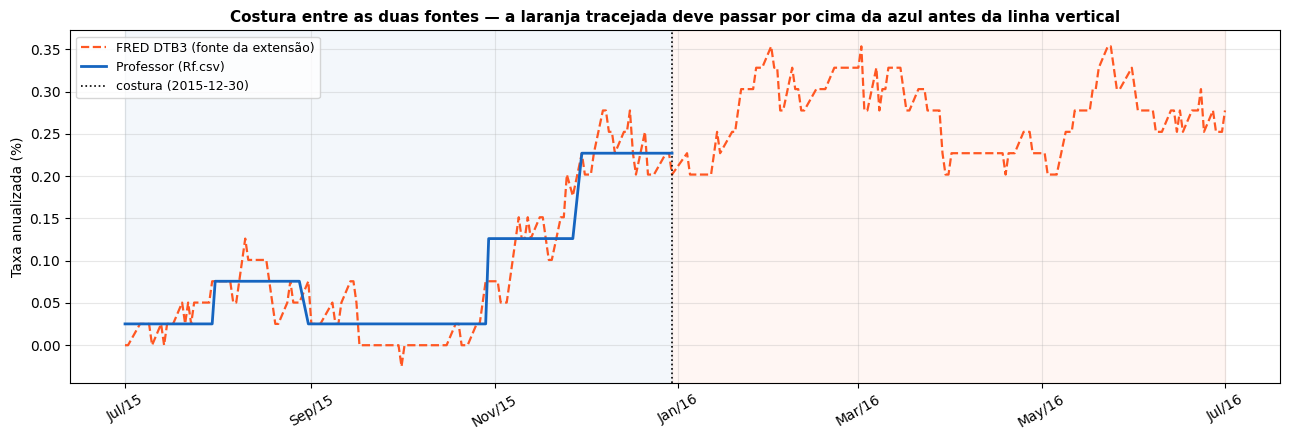

In [9]:
# 3) zoom na virada: 6 meses antes e 6 meses depois
ini, fim = '2015-07-01', '2016-07-01'
jan_prof = rf_prof.loc[ini:fim]
jan_fred = rf_fred_full.loc[ini:fim]

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(jan_fred.index, anualizar(jan_fred), color='#FF5722', lw=1.6, ls='--',
        label=f'FRED {FRED_SERIE} (fonte da extensão)', zorder=2)
ax.plot(jan_prof.index, anualizar(jan_prof), color='#1565C0', lw=2.0,
        label='Professor (Rf.csv)', zorder=3)
ax.axvline(rf_prof.index[-1], color='black', lw=1.2, ls=':',
           label=f'costura ({rf_prof.index[-1].date()})')
ax.axvspan(pd.Timestamp(ini), rf_prof.index[-1], color='#1565C0', alpha=0.05)
ax.axvspan(rf_prof.index[-1], pd.Timestamp(fim), color='#FF5722', alpha=0.05)

ax.set_title('Costura entre as duas fontes — a laranja tracejada deve passar por cima da azul antes da linha vertical',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Taxa anualizada (%)', fontsize=10)
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.tick_params(axis='x', rotation=30)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Montagem da série final

Regra da emenda: **o histórico do professor é preservado literalmente** (é o dado que gerou os resultados do artigo dele) e o FRED entra apenas a partir de 2016-01-04. A coluna `fonte` registra a origem de cada dia.

In [10]:
rf_final = pd.Series(index=datas_base, dtype=float, name='rf')
eh_prof  = datas_base <= rf_prof.index[-1]

# 1990–2015: valores do professor, na ordem das datas da base
rf_final[eh_prof] = rf_prof.reindex(datas_base[eh_prof]).values
# 2016–2025: FRED convertido
rf_final[~eh_prof] = rf_fred_full[~eh_prof].values

fonte = np.where(eh_prof, 'professor', f'FRED:{FRED_SERIE}')

# ── Taxa negativa: reportar (e opcionalmente truncar) ─────────────────────────
negativos = rf_final[rf_final < 0]
if len(negativos):
    print(f"Dias com taxa negativa: {len(negativos)} "
          f"(mínimo {anualizar(negativos.min()):.3f}% a.a.)")
    for d, v in negativos.items():
        print(f"  {d.date()} : {anualizar(v):+.3f}% a.a.")
    if PISO_ZERO:
        rf_final = rf_final.clip(lower=0)
        print("  → truncados em zero (PISO_ZERO=True)")
    else:
        print("  → mantidos (PISO_ZERO=False): é o dado de mercado real")
    print()

# ── Validações ────────────────────────────────────────────────────────────────
assert len(rf_final) == len(datas_base), 'número de linhas não bate com a base'
assert rf_final.isna().sum() == 0, f'{rf_final.isna().sum()} dias sem taxa'
assert rf_final.index.is_monotonic_increasing, 'datas fora de ordem'
assert anualizar(rf_final.max()) < 25, 'taxa implausivelmente alta — verifique a conversão'
assert (rf_prof.reindex(datas_base[eh_prof]).values == rf_final[eh_prof].values).all(), \
    'a série do professor foi alterada na emenda'

print(f"Série final : {len(rf_final):,} dias | {rf_final.index[0].date()} → {rf_final.index[-1].date()}")
print(f"  professor : {eh_prof.sum():,} dias ({rf_final.index[0].date()} → {rf_prof.index[-1].date()})")
print(f"  FRED      : {(~eh_prof).sum():,} dias ({primeira_ext.date()} → {rf_final.index[-1].date()})")
print(f"\nMédia anualizada — professor: {anualizar(rf_final[eh_prof].mean()):.2f}% a.a. | "
      f"extensão: {anualizar(rf_final[~eh_prof].mean()):.2f}% a.a.")

Dias com taxa negativa: 2 (mínimo -0.050% a.a.)
  2020-03-25 : -0.050% a.a.
  2020-03-26 : -0.050% a.a.
  → mantidos (PISO_ZERO=False): é o dado de mercado real

Série final : 8,939 dias | 1990-07-03 → 2025-12-31
  professor : 6,425 dias (1990-07-03 → 2015-12-30)
  FRED      : 2,514 dias (2016-01-04 → 2025-12-31)

Média anualizada — professor: 2.80% a.a. | extensão: 2.16% a.a.


In [11]:
saida = pd.DataFrame({'date': rf_final.index, 'rf': rf_final.values, 'fonte': fonte})
saida.to_csv(PATH_SAIDA, index=False)
print(f"Salvo em: {PATH_SAIDA}")
display(saida.head(3))
display(saida[saida['fonte'] != 'professor'].head(3))

Salvo em: ../../data_bases/rf_diario.csv


,date,rf,fonte
0,1990-07-03,0.000291,professor
1,1990-07-05,0.000291,professor
2,1990-07-06,0.000291,professor


,date,rf,fonte
6425,2016-01-04,0.000009,FRED:DTB3
6426,2016-01-05,0.000008,FRED:DTB3
6427,2016-01-06,0.000008,FRED:DTB3


## 6. Verificação final

Relê o arquivo salvo do zero (não reaproveita as variáveis da memória) e confere contra a base de preços.

In [12]:
check = pd.read_csv(PATH_SAIDA, parse_dates=['date'])
datas_ok = pd.DatetimeIndex(pd.read_csv(PATH_BASE, parse_dates=['date'], usecols=['date'])['date'])

print(f"Linhas               : {len(check):,}")
print(f"Datas idênticas à base: {check['date'].equals(pd.Series(datas_ok))}")
print(f"Valores ausentes     : {check['rf'].isna().sum()}")
print(f"Fontes               : {check['fonte'].value_counts().to_dict()}")

por_ano = check.set_index('date')['rf'].groupby(lambda d: d.year).mean()
por_ano = (((1 + por_ano) ** 252 - 1) * 100).round(2)
print("\nTaxa média anualizada por ano (%):\n")
print(por_ano.to_string())

Linhas               : 8,939
Datas idênticas à base: True
Valores ausentes     : 0
Fontes               : {'professor': 6425, 'FRED:DTB3': 2514}

Taxa média anualizada por ano (%):

date
1990    7.24
1991    5.38
1992    3.43
1993    3.00
1994    4.26
1995    5.48
1996    5.01
1997    5.06
1998    4.77
1999    4.65
2000    5.82
2001    3.38
2002    1.60
2003    1.01
2004    1.38
2005    3.16
2006    4.73
2007    4.34
2008    1.35
2009    0.16
2010    0.14
2011    0.05
2012    0.09
2013    0.06
2014    0.03
2015    0.06
2016    0.32
2017    0.93
2018    1.94
2019    2.06
2020    0.35
2021    0.05
2022    2.03
2023    5.07
2024    4.96
2025    4.06


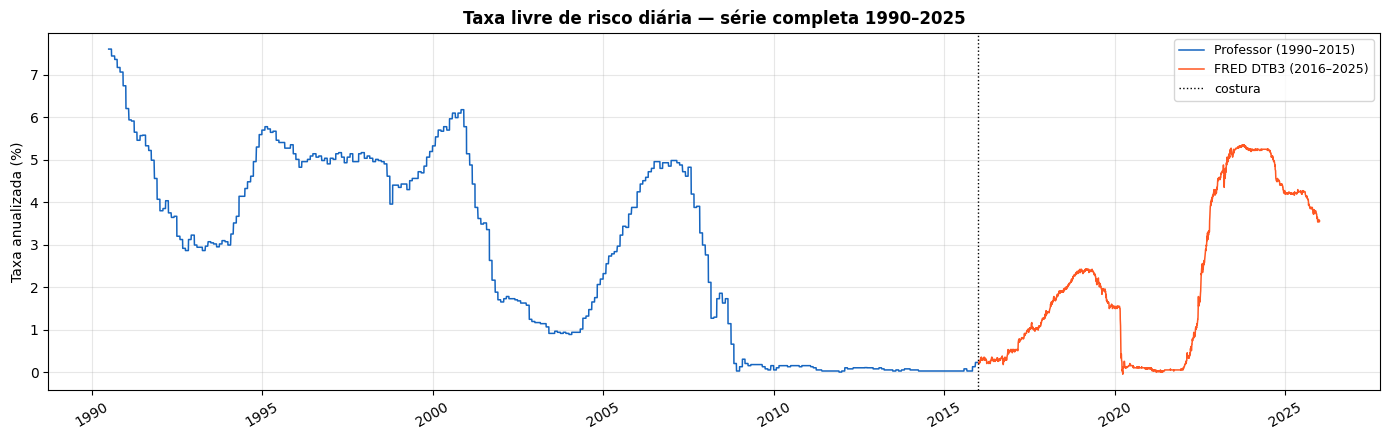

In [13]:
s = check.set_index('date')['rf']
corte = pd.Timestamp(rf_prof.index[-1])

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(s.index[s.index <= corte], anualizar(s[s.index <= corte]),
        color='#1565C0', lw=1.1, label='Professor (1990–2015)')
ax.plot(s.index[s.index > corte], anualizar(s[s.index > corte]),
        color='#FF5722', lw=1.1, label=f'FRED {FRED_SERIE} (2016–2025)')
ax.axvline(corte, color='black', lw=1.0, ls=':', label='costura')
ax.set_title('Taxa livre de risco diária — série completa 1990–2025',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Taxa anualizada (%)', fontsize=10)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.tick_params(axis='x', rotation=30)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()